### **Assignment 1**— Build Linear Regression From Scratch (No sklearn) Implement Linear Regression using Gradient Descent from scratch.

Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Load Dataset Using Pandas

In [2]:
data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Data Exploration

In [3]:
print(df.shape)
df.info()
df.describe()
df.isnull().sum()

(20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
Price,0


Handle Missing Values, Outiers

In [4]:
df = df.fillna(df.mean())

In [5]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (16312, 9)


Separate Features and Target, Train Test Split

In [6]:
X = df.drop('Price', axis=1).values
y = df['Price'].values

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Normalisation

In [8]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [9]:
m, n = X_train.shape

weights = np.zeros(n)
bias = 0

Cost Function MSE

In [10]:
def compute_cost(X, y, weights, bias):

    m = len(y)

    predictions = np.dot(X, weights) + bias

    cost = (1/(2*m)) * np.sum((predictions - y)**2)

    return cost

Grad Desc

In [11]:
def gradient_descent(X, y, weights, bias, learning_rate, iterations):

    m = len(y)

    cost_history = []

    for i in range(iterations):

        predictions = np.dot(X, weights) + bias

        dw = (1/m) * np.dot(X.T, (predictions - y))
        db = (1/m) * np.sum(predictions - y)

        weights = weights - learning_rate * dw
        bias = bias - learning_rate * db

        cost = compute_cost(X, y, weights, bias)
        cost_history.append(cost)

    return weights, bias, cost_history

Multiple learning rates

In [12]:
learning_rates = [0.001, 0.01, 0.1]

results = {}

for lr in learning_rates:

    weights = np.zeros(n)
    bias = 0

    weights, bias, cost_history = gradient_descent(
        X_train, y_train, weights, bias, lr, 1000
    )

    results[lr] = cost_history

Pot for Cost vs Iters

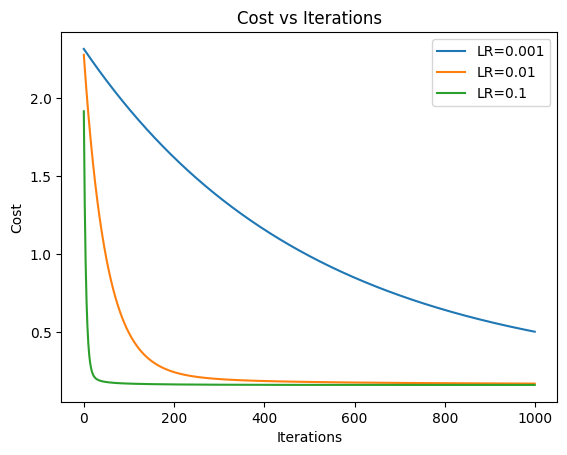

In [13]:
for lr in learning_rates:
    plt.plot(results[lr], label=f"LR={lr}")

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")
plt.legend()
plt.show()

In [14]:
predictions = np.dot(X_test, weights) + bias

In [15]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("From Scratch Model")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

From Scratch Model
MAE: 0.4234438641071253
MSE: 0.31644268201696635
RMSE: 0.5625323830829354
R2 Score: 0.6379874947274751


Evaluation Metrics

sklearn Model

In [16]:
model = LinearRegression()

model.fit(X_train, y_train)

sklearn_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, sklearn_pred)
mse = mean_squared_error(y_test, sklearn_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, sklearn_pred)

print("\nSklearn Model")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


Sklearn Model
MAE: 0.42355274297359935
MSE: 0.31652227705444747
RMSE: 0.5626031257062544
R2 Score: 0.6378964374821561


**Exrtra**

SDG

In [17]:
weights = np.zeros(n)
bias = 0

learning_rate = 0.01
epochs = 50

for epoch in range(epochs):

    for i in range(len(X_train)):

        xi = X_train[i]
        yi = y_train[i]

        prediction = np.dot(xi, weights) + bias

        error = prediction - yi

        weights = weights - learning_rate * error * xi
        bias = bias - learning_rate * error

In [18]:
sgd_pred = np.dot(X_test, weights) + bias

Evaluation using SDG

In [19]:
mae = mean_absolute_error(y_test, sgd_pred)
mse = mean_squared_error(y_test, sgd_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, sgd_pred)

print("SGD Model Results")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

SGD Model Results
MAE: 0.4330808103726334
MSE: 0.3327040534168297
RMSE: 0.5768050393476375
R2: 0.6193843791107394
